In [83]:
import sys; sys.path.append('..')
import joblib
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             f1_score, precision_score, recall_score, confusion_matrix,precision_recall_curve)
from src.features import add_features, CAT_COLS, NUM_COLS
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt


In [13]:
df = pd.read_csv('../Dataset.csv')
X = df.drop(columns='Churn')                 
y = (df['Churn'] == 'Yes').astype(int)

In [14]:
X_train_val, X_test, y_train_val, y_test= train_test_split(
    X,y,test_size=0.2, stratify=y,random_state=42
)


In [ ]:
features = FunctionTransformer(add_features)
logisticreg_pipe = Pipeline([
    ('features', features), # чистим признаки
    ('prep', ColumnTransformer([    # кодирование признаков
        ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS),
        ('num', StandardScaler(), NUM_COLS),])
    ),
    ('model', LogisticRegression(solver='saga',max_iter=5000)),
])

In [16]:
catboost_pipe = Pipeline([
    ('features', features),
    ('model', CatBoostClassifier(
        iterations=300, learning_rate=0.05, depth=6, cat_features=tuple(CAT_COLS), random_seed=42, verbose=0,
    )),
])

In [37]:
lr_search=GridSearchCV(
    logisticreg_pipe,
    param_grid={
                'model__C':[0.01,0.1,1,10],
                'model__l1_ratio':[0, 0.5, 1],
                'model__class_weight':[None, 'balanced'],
                },
    cv=5,
    scoring='average_precision'
)
lr_search.fit(X_train_val,y_train_val)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__l1_ratio': [0, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbo

In [40]:
cb_search=GridSearchCV(
    catboost_pipe,
    param_grid={
        'model__depth':[1,3,4,6,10],
        'model__learning_rate':[0.01,0.05,0.1,1],
    },
    cv=5,
    scoring='average_precision'
)
cb_search.fit(X_train_val,y_train_val)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__depth': [1, 3, ...], 'model__learning_rate': [0.01, 0.05, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls 

In [41]:
lr_best_model=lr_search.best_estimator_
cb_best_model=cb_search.best_estimator_

In [60]:
cb_proba=cross_val_predict(cb_best_model, X_train_val,y_train_val,
                           cv=5,method='predict_proba')[:,-1]
lr_proba=cross_val_predict(lr_best_model, X_train_val,y_train_val,
                                cv=5, method='predict_proba')[:,-1]

In [61]:
prec_lr,rec_lr,threeshold_lr=precision_recall_curve(y_train_val,lr_proba)
prec_cb,rec_cb,threeshold_cb=precision_recall_curve(y_train_val,cb_proba)

prec_lr,rec_lr=prec_lr[:-1],rec_lr[:-1]
prec_cb,rec_cb=prec_cb[:-1],rec_cb[:-1]


In [62]:
f1_lr=(2*prec_lr*rec_lr)/(prec_lr+rec_lr+1e-12)
f1_cb=(2*prec_cb*rec_cb)/(prec_cb+rec_cb+1e-12)

In [63]:
best_f1_lr_i=np.argmax(f1_lr)
best_f1_cb_i=np.argmax(f1_cb)
best_threeshold_lr=threeshold_lr[best_f1_lr_i]
best_threeshold_cb=threeshold_cb[best_f1_cb_i]
best_f1_lr=f1_lr[best_f1_lr_i]
best_f1_cb=f1_cb[best_f1_cb_i]

In [68]:
print(f'Log_Reg - порог: {best_threeshold_lr:.3f}   F1: {best_f1_lr:.3f}')
print(f'CatBoost - порог: {best_threeshold_cb:.3f}   F1: {best_f1_cb:.3f}')

Log_Reg - порог: 0.313   F1: 0.638
CatBoost - порог: 0.342   F1: 0.646


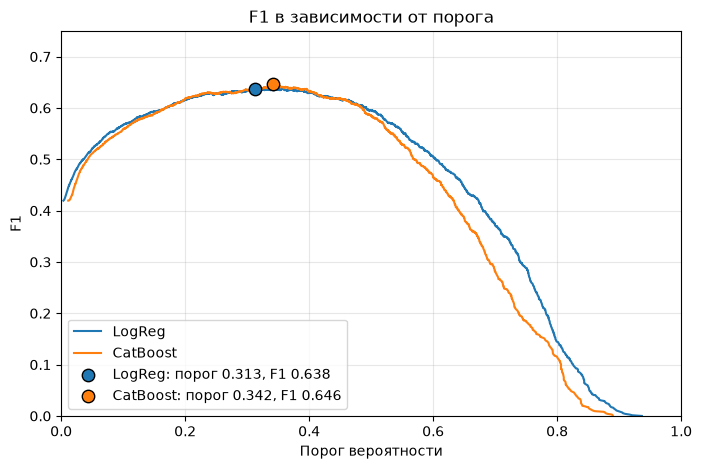

In [69]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(threeshold_lr, f1_lr, label='LogReg')
ax.plot(threeshold_cb, f1_cb, label='CatBoost')
ax.scatter(best_threeshold_lr, best_f1_lr, color='C0', s=80, zorder=3, edgecolor='black',
           label=f'LogReg: порог {best_threeshold_lr:.3f}, F1 {best_f1_lr:.3f}')
ax.scatter(best_threeshold_cb, best_f1_cb, color='C1', s=80, zorder=3, edgecolor='black',
           label=f'CatBoost: порог {best_threeshold_cb:.3f}, F1 {best_f1_cb:.3f}')
ax.set_xlabel('Порог вероятности')
ax.set_ylabel('F1')
ax.set_title('F1 в зависимости от порога')
ax.set_xlim(0, 1)
ax.set_ylim(0, 0.75)
ax.grid(alpha=0.3)
ax.legend()
plt.show()

In [78]:
final_model=cb_best_model
final_threeshold=best_threeshold_cb
test_proba=final_model.predict_proba(X_test)[:,1]
test_predict=(test_proba>=final_threeshold).astype(int)
print(f'PR-AUC:    {average_precision_score(y_test, test_proba):.3f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, test_proba):.3f}')
print(f'F1:        {f1_score(y_test, test_predict):.3f}')
print(f'Recall:    {recall_score(y_test, test_predict):.3f}')
print(f'Precision: {precision_score(y_test, test_predict):.3f}')
print()

PR-AUC:    0.670
ROC-AUC:   0.846
F1:        0.636
Recall:    0.733
Precision: 0.561



In [82]:
joblib.dump(
    {'pipeline': final_model, 'threshold': float(final_threeshold)},
    '../models/churn_pipeline.pkl',
)

['../models/churn_pipeline.pkl']